# Phase 4 — Modelling

This phase trains and runs three parallel classifiers on the cleaned corpus. Each track answers a different question:

| Track | Model | Question answered |
|---|---|---|
| **A** | kNN + Sentence-Transformers | Does this passage *mean* the same thing as known greenwashing? |
| **B** | TF-IDF + Logistic Regression | Does this passage *contain* the same keywords as known greenwashing? |
| **C** | ClimateBERT framing (`climate-f`) | Is this claim framed as a climate *opportunity* or *risk*? |

Tracks A and B produce greenwash probability scores for every passage. Where they **agree**, the prediction is confident. Where they **disagree**, the passage is flagged for manual review. Track C adds a framing dimension — a passage that scores high on greenwashing risk AND is framed as an "opportunity" is the clearest red flag.

### Pipeline Overview
**`labeled_passages.jsonl` + embeddings → train → predict on full corpus → `knn_predictions.parquet` + `tfidf_predictions.parquet` + `climatebert_predictions.parquet`**

### Outputs
| File | Contents |
|---|---|
| `results/knn_predictions.parquet` | kNN greenwash probability for every corpus passage + nearest neighbours |
| `results/tfidf_predictions.parquet` | TF-IDF + LR greenwash probability for every corpus passage |
| `results/climatebert_predictions.parquet` | ClimateBERT framing label (opportunity/risk/neutral) for every corpus passage |
| `results/best_k.txt` | Best k from cross-validation, saved for downstream evaluation notebook |

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from transformers import pipeline as hf_pipeline
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt

In [2]:
ROOT       = Path('..').resolve()
FEAT_DIR   = ROOT / 'data' / 'features'
LABELED    = ROOT / 'data' / 'labeled' / 'labeled_passages.jsonl'
TEST_SET   = ROOT / 'data' / 'labeled' / 'test_set.jsonl'
PASSAGES   = ROOT / 'data' / 'extracted' / 'passages.jsonl'
RESULTS    = ROOT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)
CARBON_DIR = RESULTS / 'carbon'
CARBON_DIR.mkdir(parents=True, exist_ok=True)

# Load corpus (all passages) and training set (manually labeled, label 0 or 1)
with open(PASSAGES) as f:
    corpus = [json.loads(l) for l in f]
with open(LABELED) as f:
    labeled = [json.loads(l) for l in f]

corpus_texts  = [p['text'] for p in corpus]
train_texts   = [p['text'] for p in labeled]
train_labels  = [p['label'] for p in labeled]

# Load pre-computed sentence embeddings (all-MiniLM-L6-v2, 384-dim, L2-normalized)
X_corpus  = np.load(FEAT_DIR / 'corpus_embeddings.npy')
X_train   = np.load(FEAT_DIR / 'labeled_embeddings.npy')

print(f"Corpus: {len(corpus_texts):,}  |  Train: {len(train_texts)}  |  Classes: {set(train_labels)}")

Corpus: 4,485  |  Train: 92  |  Classes: {0, 1}


In [3]:
tracker = EmissionsTracker(
    project_name="green-claims-nlp",
    output_dir=str(CARBON_DIR),
    output_file="emissions.csv",
    log_level="error",
)
tracker.start()
print("Carbon tracking started.")

[codecarbon WARNING @ 23:47:20] Multiple instances of codecarbon are allowed to run at the same time.


Carbon tracking started.


## Track A — kNN on Sentence Embeddings (primary model)

Each passage has been encoded as a 384-dimensional vector by `all-MiniLM-L6-v2`. The kNN classifier finds the *k* most similar training passages by cosine distance and votes on the label.

**Why cosine distance?** Embeddings are L2-normalized, so cosine distance equals Euclidean distance. This means `brute`-force search is exact and fast at this scale (~1,300 passages).

**Why kNN over a fine-tuned classifier?** The training set is small (92 passages). kNN makes no parametric assumptions and degrades gracefully with small N — a fine-tuned model would overfit.

**Steps:**
1. **k-tuning** — test k ∈ {3, 5, 7, 10} with 5-fold cross-validation (F1 macro), save best k
2. **Calibration check** — plot predicted probabilities vs. actual fraction of positives; a well-calibrated model hugs the diagonal
3. **Corpus prediction** — fit on full training set, predict probability of greenwashing for every corpus passage; save top-3 nearest training neighbors for each flagged passage so predictions are interpretable

In [4]:
# Tune k = 3, 5, 7, 10 via 5-fold cross-validation on training set
print("k-tuning via 5-fold CV (F1 macro):")
best_k, best_f1 = 5, -1
for k in [3, 5, 7, 10]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute')
    scores = cross_val_score(knn, X_train, train_labels, cv=5, scoring='f1_macro')
    print(f"  k={k:2d}  F1={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_f1:
        best_k, best_f1 = k, scores.mean()

print(f"\nBest k = {best_k}  (F1 = {best_f1:.3f})")

# Persist best_k so downstream evaluation can load it without re-tuning
with open(RESULTS / 'best_k.txt', 'w') as f:
    f.write(str(best_k))
print(f"Saved best_k={best_k} → {RESULTS / 'best_k.txt'}")

k-tuning via 5-fold CV (F1 macro):
  k= 3  F1=0.657 ± 0.097
  k= 5  F1=0.680 ± 0.155
  k= 7  F1=0.746 ± 0.117
  k=10  F1=0.688 ± 0.120

Best k = 7  (F1 = 0.746)
Saved best_k=7 → /Users/mandy.sun/green-claims-nlp/results/best_k.txt


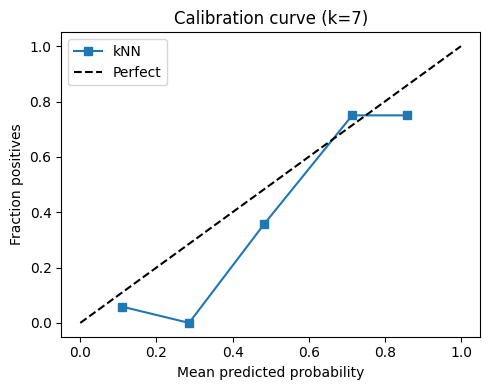

In [5]:
# Calibration check on held-out CV fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_probs, all_true = [], []
for train_idx, val_idx in skf.split(X_train, train_labels):
    knn_cv = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
    knn_cv.fit(X_train[train_idx], [train_labels[i] for i in train_idx])
    probs = knn_cv.predict_proba(X_train[val_idx])[:, 1]
    all_probs.extend(probs)
    all_true.extend([train_labels[i] for i in val_idx])

frac_pos, mean_pred = calibration_curve(all_true, all_probs, n_bins=5)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(mean_pred, frac_pos, 's-', label='kNN')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set(xlabel='Mean predicted probability', ylabel='Fraction positives',
       title=f'Calibration curve (k={best_k})')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
knn.fit(X_train, train_labels)
knn_preds  = knn.predict(X_corpus)
knn_probs  = knn.predict_proba(X_corpus)[:, 1]   # P(greenwash)

# For every corpus passage, retrieve its top-k nearest training neighbors
# (used downstream for explainability: "this passage is flagged because it resembles X")
distances, indices = knn.kneighbors(X_corpus)

# Build results dataframe
knn_df = pd.DataFrame({
    'passage_id':   [p['passage_id'] for p in corpus],
    'brand':        [p['brand'] for p in corpus],
    'industry':     [p['industry'] for p in corpus],
    'role':         [p['role'] for p in corpus],
    'knn_pred':     knn_preds,
    'knn_prob':     knn_probs.round(4),
    'nn_indices':   [idx.tolist() for idx in indices],
    'nn_distances': [dist.tolist() for dist in distances],
})
knn_df.to_parquet(RESULTS / 'knn_predictions.parquet', index=False)
print(f"Saved → {RESULTS / 'knn_predictions.parquet'}")
print(f"Passages flagged (prob > 0.6): {(knn_df['knn_prob'] > 0.6).sum():,}")

Saved → /Users/mandy.sun/green-claims-nlp/results/knn_predictions.parquet
Passages flagged (prob > 0.6): 703


## Track B — TF-IDF + Logistic Regression (lexical baseline)

This is a bag-of-words model trained on unigrams and bigrams. It answers a different question than kNN: instead of *semantic similarity*, it looks for **specific words and phrases** that correlate with greenwashing.

**Text normalisation:** Text is lowercased and stopwords are removed. No stemming is applied — word forms are kept intact so the logistic regression coefficients remain human-readable ("committed" stays "committed", not "commit"). The interpretability payoff on this small corpus outweighs any marginal accuracy gain from vocabulary compression.

**Why `class_weight='balanced'`?** The training set is imbalanced (~70% substantive, ~30% greenwash-risk). Balancing re-weights the loss so the minority class isn't ignored.

**Interpretation:** Feature importances from the logistic regression coefficients can be extracted to see which words are most predictive of greenwashing — useful for understanding what the model is picking up on and for poster figures.

In [19]:
_STOP = {
    # common English stopwords
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','shall','should','may','might','must',
    'can','could','this','that','these','those','it','its','we','our',
    'they','their','by','from','as','not','no','so','if','all','also',
    'more','than','about','which','there','each','other',
    # brand names and common variants — excluded so the model can't memorize brand identity
    'hm','zara','shein','kering','lululemon','ralph','lauren','ralphlauren',
    'puma','everlane','patagonia','eileen','fisher','eileenfisher',
    'reformation','loreal','oreal','unilever','sephora','lush',
    'loccitane','occitane',
}

def normalize_text(text: str) -> str:
    """Lowercase and remove stopwords (including brand names). No stemming — preserves word forms for interpretability."""
    tokens = re.findall(r'[a-z]+', text.lower())
    return ' '.join(t for t in tokens if t not in _STOP and len(t) > 2)

lemmatized_train  = [normalize_text(t) for t in train_texts]
lemmatized_corpus = [normalize_text(t) for t in corpus_texts]
print(f"Normalization done. Example:")
print(f"  IN:  {train_texts[0][:80]}")
print(f"  OUT: {lemmatized_train[0][:80]}")

Normalization done. Example:
  IN:  Sharing resources brings shared success To achieve our ambitious goals, we have 
  OUT: sharing resources brings shared success achieve ambitious goals shared operation


In [20]:
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
baseline.fit(lemmatized_train, train_labels)
tfidf_preds = baseline.predict(lemmatized_corpus)
tfidf_probs = baseline.predict_proba(lemmatized_corpus)[:, 1]

tfidf_df = pd.DataFrame({
    'passage_id':  [p['passage_id'] for p in corpus],
    'brand':       [p['brand'] for p in corpus],
    'industry':    [p['industry'] for p in corpus],
    'role':        [p['role'] for p in corpus],
    'tfidf_pred':  tfidf_preds,
    'tfidf_prob':  tfidf_probs.round(4),
})
tfidf_df.to_parquet(RESULTS / 'tfidf_predictions.parquet', index=False)
print(f"Saved → {RESULTS / 'tfidf_predictions.parquet'}")
print(f"Passages flagged (prob > 0.6): {(tfidf_df['tfidf_prob'] > 0.6).sum():,}")

Saved → /Users/mandy.sun/green-claims-nlp/results/tfidf_predictions.parquet
Passages flagged (prob > 0.6): 44


## Track C — ClimateBERT Commitment Classifier

`climatebert/distilroberta-base-climate-commitment` classifies whether a climate commitment is **vague** ("we aim to be more sustainable") or **specific** ("we will reduce Scope 1 emissions 50% by 2030"). This maps directly onto our label schema:
- **Vague** ≈ greenwash-risk: unverifiable, aspirational language
- **Specific** ≈ substantive: concrete, measurable, time-bound

This is a corroborating signal, not a replacement for Tracks A/B. It was trained on generic climate text rather than our labeled data, so it won't catch all greenwashing — but when Track A/B and Track C all agree a passage is vague/high-risk, that convergence is strong evidence.

**Note on label names:** We inspect `id2label` from the model config after loading to confirm label mapping before saving.

In [13]:
import shutil

cb_path = RESULTS / 'climatebert_predictions.parquet'
if shutil.disk_usage('/').free < 400 * 1024 * 1024:
    print("Insufficient disk space (need ~400 MB). Skipping Track C.")
    cb_df = pd.DataFrame({
        'passage_id': [p['passage_id'] for p in corpus],
        'brand':      [p['brand'] for p in corpus],
        'industry':   [p['industry'] for p in corpus],
        'role':       [p['role'] for p in corpus],
        'cb_label':   ['SKIPPED'] * len(corpus),
        'cb_score':   [0.0] * len(corpus),
    })
    cb_df.to_parquet(cb_path, index=False)
    print(f"Saved stub → {cb_path}")
else:
    climatebert_clf = hf_pipeline(
        "text-classification",
        model="climatebert/distilroberta-base-climate-commitment",
        truncation=True,
        max_length=512,
        device=-1,
    )

    # Confirm label mapping (expect something like {0: 'Vague', 1: 'Specific'})
    id2label = climatebert_clf.model.config.id2label
    print(f"ClimateBERT commitment label mapping: {id2label}")

    BATCH = 64
    cb_preds = []
    for i in range(0, len(corpus_texts), BATCH):
        batch = corpus_texts[i : i + BATCH]
        cb_preds.extend(climatebert_clf(batch))
        if i % 500 == 0:
            print(f"  {i:>6,}/{len(corpus_texts):,}...")

    # Map raw label IDs to human-readable names
    def map_label(raw: str) -> str:
        try:
            return id2label.get(int(raw.split('_')[-1]), raw)
        except (ValueError, AttributeError):
            return raw

    cb_df = pd.DataFrame({
        'passage_id': [p['passage_id'] for p in corpus],
        'brand':      [p['brand'] for p in corpus],
        'industry':   [p['industry'] for p in corpus],
        'role':       [p['role'] for p in corpus],
        'cb_label':   [map_label(r['label']) for r in cb_preds],
        'cb_score':   [round(r['score'], 4) for r in cb_preds],
    })
    cb_df.to_parquet(cb_path, index=False)
    print(f"\nSaved → {cb_path}")
    print("\nClimateBERT commitment label distribution:")
    print(cb_df['cb_label'].value_counts())

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-commitment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

ClimateBERT commitment label mapping: {0: 'no', 1: 'yes'}
       0/4,485...

Saved → /Users/mandy.sun/green-claims-nlp/results/climatebert_predictions.parquet

ClimateBERT commitment label distribution:
cb_label
yes    3396
no     1089
Name: count, dtype: int64


## Test Set Evaluation

The test set (48 held-out passages, locked in Phase 2) is used here for a single final evaluation. **Do not adjust model choices based on these numbers** — the test set should only be examined once, after all modeling decisions have been made.

Test passages are part of the full corpus, so their embeddings already exist in `corpus_embeddings.npy`. We look up each test passage by `passage_id` to retrieve its pre-computed embedding for Track A evaluation.

Metrics reported:
- **Precision / Recall / F1** per class (substantive and greenwash-risk)
- **AUC-ROC** — overall discriminative ability regardless of threshold

In [16]:
# Load test set
# Note: test passages use annotation_id (from the labeling phase), not passage_id.
# They are not guaranteed to exist in the corpus parquet, so we encode them directly.
with open(TEST_SET) as f:
    test_set = [json.loads(l) for l in f]

y_test      = [p['label'] for p in test_set]
test_texts  = [p['text'] for p in test_set]

print(f"Test set: {len(test_set)} passages  |  Classes: {dict(pd.Series(y_test).value_counts())}")

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize as sk_normalize

embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_test = sk_normalize(
    embedder.encode(test_texts, batch_size=64, show_progress_bar=False, convert_to_numpy=True),
    norm='l2',
)
print(f"Test embeddings: {X_test.shape}")

# --- Track A ---
knn_test_preds = knn.predict(X_test)
knn_test_probs = knn.predict_proba(X_test)[:, 1]

# --- Track B ---
normalized_test  = [normalize_text(t) for t in test_texts]
tfidf_test_preds = baseline.predict(normalized_test)
tfidf_test_probs = baseline.predict_proba(normalized_test)[:, 1]

TARGET_NAMES = ['Substantive', 'Greenwash-risk']

print("\n=== Track A — kNN ===")
print(classification_report(y_test, knn_test_preds, target_names=TARGET_NAMES))
print(f"AUC-ROC: {roc_auc_score(y_test, knn_test_probs):.3f}")

print("\n=== Track B — TF-IDF + LR ===")
print(classification_report(y_test, tfidf_test_preds, target_names=TARGET_NAMES))
print(f"AUC-ROC: {roc_auc_score(y_test, tfidf_test_probs):.3f}")

Test set: 48 passages  |  Classes: {0: np.int64(34), 1: np.int64(14)}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test embeddings: (48, 384)

=== Track A — kNN ===
                precision    recall  f1-score   support

   Substantive       0.92      0.68      0.78        34
Greenwash-risk       0.52      0.86      0.65        14

      accuracy                           0.73        48
     macro avg       0.72      0.77      0.71        48
  weighted avg       0.80      0.73      0.74        48

AUC-ROC: 0.874

=== Track B — TF-IDF + LR ===
                precision    recall  f1-score   support

   Substantive       0.85      0.82      0.84        34
Greenwash-risk       0.60      0.64      0.62        14

      accuracy                           0.77        48
     macro avg       0.72      0.73      0.73        48
  weighted avg       0.78      0.77      0.77        48

AUC-ROC: 0.861


In [15]:
emissions = tracker.stop()
print(f"Total modeling emissions: {emissions:.4f} kg CO2e")
print(f"Saved to: {CARBON_DIR / 'emissions.csv'}")

Total modeling emissions: 0.0013 kg CO2e
Saved to: /Users/mandy.sun/green-claims-nlp/results/carbon/emissions.csv
